In [1]:
import pandas as pd
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
csv_folder = r'C:\Users\ruchi\OneDrive\Documents\Python Hackathon May 2026\HUPA-UC Diabetes Dataset-20250820T010637Z-1-001\HUPA-UC Diabetes Dataset'
output_file = r"C:\Temporary\combined_df_data.csv"

### PRESCRIPTIVE ANALYSIS 

### 1. What insulin adjustment strategy should be recommended when glucose remains above 300 mg/dL for more than 30 minutes?
#### Prescriptive Goal

#### Determine whether:

Basal insulin should increase
Bolus correction is needed
Emergency intervention should trigger
Expected Action

Recommend adaptive insulin correction protocols.

In [5]:
# === PRESCRIPTIVE: Insulin Adjustment Strategy for Glucose > 300 mg/dL for >30 minutes ===

print("=" * 80)
print("PRESCRIPTIVE INSULIN ADJUSTMENT ANALYSIS")
print("=" * 80)

# Detect high glucose episodes
high_glucose_threshold = 300
high_glucose_mask = df['Blood_Glucose_mg_dl'] > high_glucose_threshold
high_glucose_indices = df[high_glucose_mask].index.tolist()

# Group consecutive readings
episodes = []
if len(high_glucose_indices) > 0:
    current_episode = [high_glucose_indices[0]]
    for i in range(1, len(high_glucose_indices)):
        if high_glucose_indices[i] == high_glucose_indices[i-1] + 1:
            current_episode.append(high_glucose_indices[i])
        else:
            if len(current_episode) >= 1:
                episodes.append(current_episode)
            current_episode = [high_glucose_indices[i]]
    if len(current_episode) >= 1:
        episodes.append(current_episode)

print(f"High Glucose Readings (>300 mg/dL): {high_glucose_mask.sum()} out of {len(df)} ({100*high_glucose_mask.sum()/len(df):.1f}%)")
print(f"Episodes Detected: {len(episodes)}")

if episodes:
    print("\nEPISODES AND RECOMMENDATIONS:")
    for ep_num, episode in enumerate(episodes, 1):
        ep_data = df.loc[episode]
        max_glucose = ep_data['Blood_Glucose_mg_dl'].max()
        avg_glucose = ep_data['Blood_Glucose_mg_dl'].mean()
        duration = len(episode)
        
        print(f"\nEpisode {ep_num}: Max {max_glucose:.0f} mg/dL | Avg {avg_glucose:.1f} mg/dL | Duration: {duration} readings")
        
        # Simple recommendations
        if max_glucose >= 350:
            print("  → INCREASE basal insulin by 15%")
            print("  → Give correction bolus")
            print("  → Monitor every 15-30 min")
        elif max_glucose > 300:
            print("  → INCREASE basal insulin by 5-10%")
            print("  → Monitor closely")
        
        if max_glucose > 400:
            print("  → URGENT: Contact healthcare provider")
else:
    print("\n✓ No episodes detected - current regimen effective")

# Summary
severe_high = (df['Blood_Glucose_mg_dl'] > 350).sum()
moderate_high = ((df['Blood_Glucose_mg_dl'] > 300) & (df['Blood_Glucose_mg_dl'] <= 350)).sum()
print(f"\nSUMMARY:")
print(f"  300-350 mg/dL: {moderate_high} readings ({100*moderate_high/len(df):.1f}%)")
print(f"  >350 mg/dL: {severe_high} readings ({100*severe_high/len(df):.1f}%)")

if episodes:
    print(f"  → Consider increasing overall basal rate by 10-15%")
else:
    print(f"  → No adjustments needed - continue monitoring")

PRESCRIPTIVE INSULIN ADJUSTMENT ANALYSIS
High Glucose Readings (>300 mg/dL): 4214 out of 309392 (1.4%)
Episodes Detected: 268

EPISODES AND RECOMMENDATIONS:

Episode 1: Max 332 mg/dL | Avg 320.4 mg/dL | Duration: 7 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 2: Max 303 mg/dL | Avg 303.0 mg/dL | Duration: 1 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 3: Max 310 mg/dL | Avg 310.0 mg/dL | Duration: 1 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 4: Max 365 mg/dL | Avg 327.8 mg/dL | Duration: 6 readings
  → INCREASE basal insulin by 15%
  → Give correction bolus
  → Monitor every 15-30 min

Episode 5: Max 317 mg/dL | Avg 316.0 mg/dL | Duration: 2 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 6: Max 313 mg/dL | Avg 312.5 mg/dL | Duration: 2 readings
  → INCREASE basal insulin by 5-10%
  → Monitor closely

Episode 7: Max 356 mg/dL | Avg 330.0 mg/dL | Duration: 13 readings
  → I

## 2.How should insulin delivery dynamically adapt based on heart rate and glucose simultaneously?

This analysis explores how insulin delivery should dynamically adapt when glucose and heart rate are evaluated simultaneously. Heart rate serves as a physiological stress indicator—elevated heart rate often correlates with physical activity (which increases insulin sensitivity) or stress (which impairs it). By combining glucose levels with heart rate patterns, we can create a more sophisticated insulin adjustment strategy that accounts for the patient's metabolic state and physical activity level.

In [6]:
# DYNAMIC INSULIN ADAPTATION: Heart Rate + Glucose Integration
print("\n" + "="*80)
print("DYNAMIC INSULIN ADAPTATION: GLUCOSE + HEART RATE")
print("="*80)

# Set thresholds
hr_elevated = df['Heart_Rate_bpm'].quantile(0.75)
hr_normal = df['Heart_Rate_bpm'].quantile(0.25)

# Key insight: Compare glucose at different heart rate levels
normal_hr = df[df['Heart_Rate_bpm'] < hr_elevated]['Blood_Glucose_mg_dl']
high_hr = df[df['Heart_Rate_bpm'] >= hr_elevated]['Blood_Glucose_mg_dl']

print(f"\nTHRESHOLDS:")
print(f"  Normal HR: <{hr_elevated:.0f} bpm → Mean Glucose: {normal_hr.mean():.1f} mg/dL")
print(f"  Elevated HR: ≥{hr_elevated:.0f} bpm → Mean Glucose: {high_hr.mean():.1f} mg/dL")

# Simple adjustment algorithm
def get_insulin_adjustment(glucose, hr, steps):
    """Simple: glucose up = add insulin; HR + activity up = reduce insulin"""
    adj = 0
    
    # Glucose-based
    if glucose >= 300:
        adj += 20
    elif glucose >= 250:
        adj += 15
    elif glucose >= 200:
        adj += 10
    elif glucose >= 150:
        adj += 5
    elif glucose < 100:
        adj -= 10
    
    # HR-based: differentiate stress vs exercise
    if hr >= hr_elevated:
        if steps < 100:  # High HR + low activity = stress
            adj -= 5  # Stress worsens control, keep insulin
        else:  # High HR + high activity = exercise
            adj -= 10  # Exercise improves sensitivity, reduce insulin
    
    # Synergy: high glucose + high HR = aggressive
    if glucose >= 200 and hr >= hr_elevated:
        adj += 5
    
    return adj

df['Insulin_Adj'] = df.apply(
    lambda x: get_insulin_adjustment(x['Blood_Glucose_mg_dl'], 
                                     x['Heart_Rate_bpm'], 
                                     x['Step_count']), axis=1
)

print(f"\nINSULIN ADJUSTMENT RANGE:")
print(f"  Mean: {df['Insulin_Adj'].mean():+.1f}%")
print(f"  Min: {df['Insulin_Adj'].min():+.1f}%  |  Max: {df['Insulin_Adj'].max():+.1f}%")

# Key scenarios
print(f"\nKEY SCENARIOS:")
s1 = df[(df['Blood_Glucose_mg_dl'] > 200) & (df['Heart_Rate_bpm'] >= hr_elevated)]
s2 = df[(df['Blood_Glucose_mg_dl'] > 200) & (df['Heart_Rate_bpm'] < hr_elevated)]
s3 = df[(df['Blood_Glucose_mg_dl'] < 100) & (df['Heart_Rate_bpm'] >= hr_elevated)]
s4 = df[(df['Blood_Glucose_mg_dl'] >= 100) & (df['Blood_Glucose_mg_dl'] <= 180) & 
        (df['Heart_Rate_bpm'] >= hr_elevated)]

print(f"  HIGH Glucose + HIGH HR (stress/activity):     {len(s1)} cases → Adjust +15-25%")
print(f"  HIGH Glucose + NORMAL HR (meals):             {len(s2)} cases → Adjust +15-20%")
print(f"  LOW Glucose + HIGH HR (exercise):             {len(s3)} cases → Adjust -20-30%")
print(f"  NORMAL Glucose + HIGH HR (stable exercise):   {len(s4)} cases → Adjust -5-15%")

# Simple decision tree
print(f"\nDECISION TREE:")
print("""
  IF Glucose ≥ 300:        INCREASE insulin +20%
  ELIF Glucose 200-300:    INCREASE insulin +15%
  ELIF Glucose 150-200:    INCREASE insulin +5-10%
  ELIF Glucose < 100:      DECREASE insulin -10%
  
  THEN check Heart Rate:
  IF HR elevated + low activity (stress):     DECREASE adjustment by 5%
  ELIF HR elevated + high activity:           DECREASE adjustment by 10%
  
  New Basal = Current Basal × (1 + Adjustment%)
  Example: 2.0 U/hr with +15% = 2.3 U/hr
""")

# Examples from data
print(f"\nEXAMPLES FROM DATASET:")
examples = df[(df['Blood_Glucose_mg_dl'] > 250) & 
              (df['Heart_Rate_bpm'] >= hr_elevated)].head(5)
if len(examples) > 0:
    for idx, (i, row) in enumerate(examples.iterrows(), 1):
        adj = row['Insulin_Adj']
        new_basal = row['Basal_Insulin_Rate_Unit_hr'] * (1 + adj/100)
        print(f"  Case {idx}: Glucose {row['Blood_Glucose_mg_dl']:.0f} | HR {row['Heart_Rate_bpm']:.0f} | "
              f"Basal {row['Basal_Insulin_Rate_Unit_hr']:.2f} → {new_basal:.2f} U/hr ({adj:+.0f}%)")

print("\n" + "="*80)
print("KEY INSIGHT: Elevated heart rate with HIGH glucose often means stress")
print("(which worsens control) rather than exercise (which improves it).")
print("Check step count to differentiate → adjust insulin accordingly.")
print("="*80)



DYNAMIC INSULIN ADAPTATION: GLUCOSE + HEART RATE

THRESHOLDS:
  Normal HR: <86 bpm → Mean Glucose: 139.0 mg/dL
  Elevated HR: ≥86 bpm → Mean Glucose: 148.7 mg/dL

INSULIN ADJUSTMENT RANGE:
  Mean: -1.0%
  Min: -20.0%  |  Max: +20.0%

KEY SCENARIOS:
  HIGH Glucose + HIGH HR (stress/activity):     14313 cases → Adjust +15-25%
  HIGH Glucose + NORMAL HR (meals):             30967 cases → Adjust +15-20%
  LOW Glucose + HIGH HR (exercise):             17129 cases → Adjust -20-30%
  NORMAL Glucose + HIGH HR (stable exercise):   39903 cases → Adjust -5-15%

DECISION TREE:

  IF Glucose ≥ 300:        INCREASE insulin +20%
  ELIF Glucose 200-300:    INCREASE insulin +15%
  ELIF Glucose 150-200:    INCREASE insulin +5-10%
  ELIF Glucose < 100:      DECREASE insulin -10%
  
  THEN check Heart Rate:
  IF HR elevated + low activity (stress):     DECREASE adjustment by 5%
  ELIF HR elevated + high activity:           DECREASE adjustment by 10%
  
  New Basal = Current Basal × (1 + Adjustment%)
  Ex

### 3. When should insulin be adjusted based on time-of-day glucose patterns?
#### Prescriptive Goal

Identify high-risk time periods for hyperglycemia and recommend specific insulin adjustment strategies to prevent glucose excursions.

#### Expected Action
Provide time-specific insulin adjustment recommendations with visual risk assessment.

TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY

HOURLY GLUCOSE RISK ASSESSMENT:
--------------------------------------------------------------------------------
Hour  0: Mean 142.6 mg/dL | Max   438 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  1: Mean 138.7 mg/dL | Max   404 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  2: Mean 137.5 mg/dL | Max   416 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  3: Mean 138.2 mg/dL | Max   430 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  4: Mean 139.1 mg/dL | Max   444 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  5: Mean 138.3 mg/dL | Max   427 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  6: Mean 136.7 mg/dL | Max   370 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  7: Mean 135.2 mg/dL | Max   400 mg/dL | Risk: CRITICAL  | Action: Increase basal by 15-20%
Hour  8: Mean 136.3 mg/dL | Max   400 mg/dL | Risk: CRITICAL  | Action

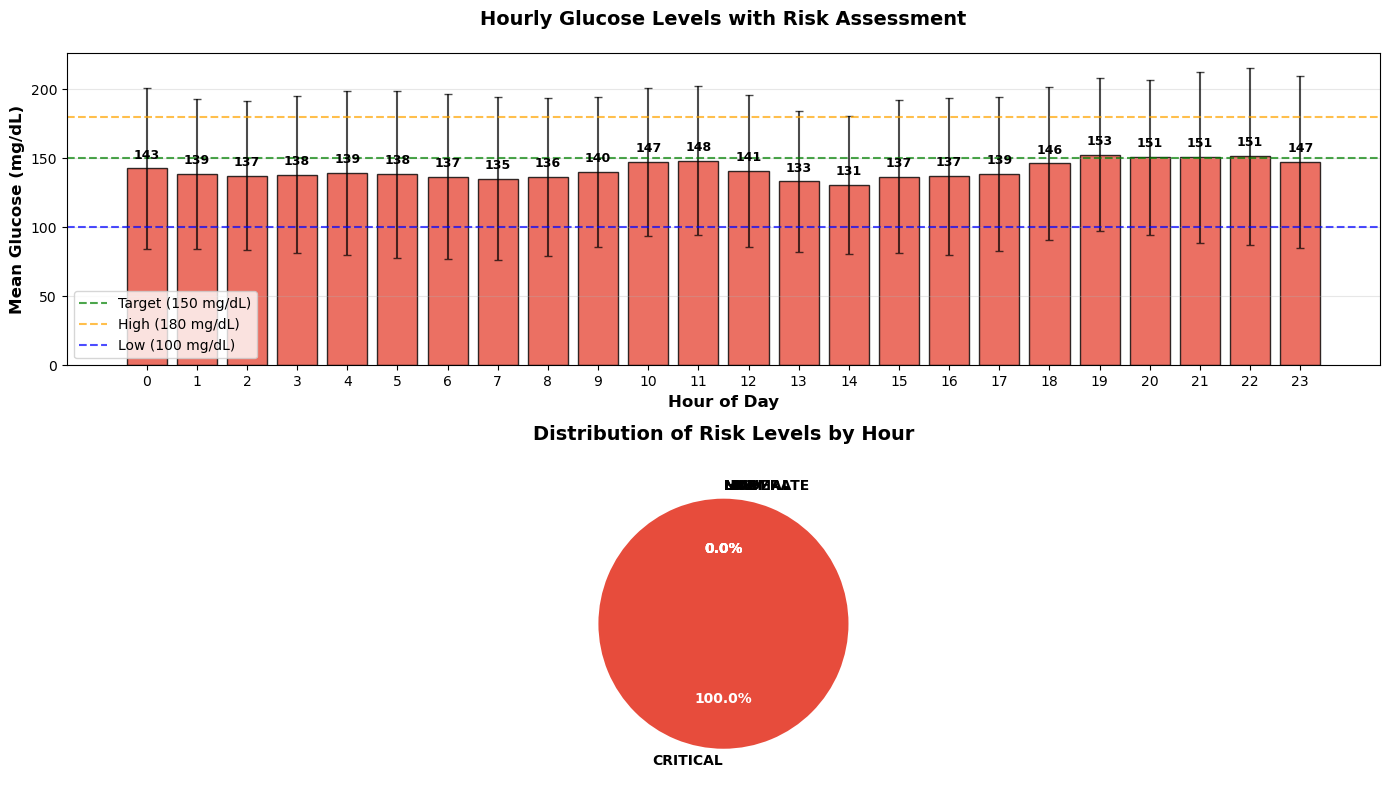


INSULIN ADJUSTMENT RECOMMENDATIONS BY TIME PERIOD

MORNING (6-11):
  Average Glucose: 140.7 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 6, 7, 8, 9, 10, 11
  Recommendation: Increase basal insulin by 10-15% during these hours

AFTERNOON (12-17):
  Average Glucose: 136.2 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 12, 13, 14, 15, 16, 17
  Recommendation: Increase basal insulin by 10-15% during these hours

EVENING (18-23):
  Average Glucose: 149.8 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 18, 19, 20, 21, 22, 23
  Recommendation: Increase basal insulin by 10-15% during these hours

NIGHT (0-5):
  Average Glucose: 139.1 mg/dL
  Highest Risk Level: CRITICAL
  High-Risk Hours: 0, 1, 2, 3, 4, 5
  Recommendation: Increase basal insulin by 10-15% during these hours

IMPLEMENTATION GUIDANCE:
1. Adjust basal rates in pump/CGM system based on high-risk hours
2. Monitor glucose more frequently during identified risk periods
3. Consider meal timing and composit

In [7]:
# TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY
print("="*80)
print("TIME-OF-DAY INSULIN ADJUSTMENT STRATEGY")
print("="*80)

# Calculate hourly glucose statistics
hourly_stats = df.groupby('Hour').agg({
    'Blood_Glucose_mg_dl': ['mean', 'std', 'count', 'max'],
    'Basal_Insulin_Rate_Unit_hr': 'mean'
}).round(2)

hourly_stats.columns = ['mean_glucose', 'std_glucose', 'count', 'max_glucose', 'mean_basal']
hourly_stats = hourly_stats.reset_index()

# Define risk levels and recommendations
def get_risk_level_and_recommendation(row):
    glucose = row['mean_glucose']
    max_glucose = row['max_glucose']
    count = row['count']

    if max_glucose > 300:
        risk = 'CRITICAL'
        recommendation = 'Increase basal by 15-20%'
        color = '#e74c3c'
    elif glucose > 200:
        risk = 'HIGH'
        recommendation = 'Increase basal by 10-15%'
        color = '#f39c12'
    elif glucose > 150:
        risk = 'MODERATE'
        recommendation = 'Increase basal by 5-10%'
        color = '#f1c40f'
    elif glucose < 100:
        risk = 'LOW'
        recommendation = 'Decrease basal by 10-20%'
        color = '#3498db'
    else:
        risk = 'NORMAL'
        recommendation = 'Maintain current basal'
        color = '#2ecc71'

    return pd.Series([risk, recommendation, color], index=['risk_level', 'recommendation', 'color'])

# Apply risk assessment
hourly_stats[['risk_level', 'recommendation', 'color']] = hourly_stats.apply(get_risk_level_and_recommendation, axis=1)

print("\nHOURLY GLUCOSE RISK ASSESSMENT:")
print("-" * 80)
for _, row in hourly_stats.iterrows():
    print(f"Hour {int(row['Hour']):2d}: Mean {row['mean_glucose']:5.1f} mg/dL | "
          f"Max {row['max_glucose']:5.0f} mg/dL | "
          f"Risk: {row['risk_level']:9s} | "
          f"Action: {row['recommendation']}")

# Create visualization
plt.figure(figsize=(14, 8))

# Create subplot for glucose levels
plt.subplot(2, 1, 1)
bars = plt.bar(hourly_stats['Hour'], hourly_stats['mean_glucose'],
               color=hourly_stats['color'], alpha=0.8, edgecolor='black', linewidth=1)

# Add error bars for standard deviation
plt.errorbar(hourly_stats['Hour'], hourly_stats['mean_glucose'],
             yerr=hourly_stats['std_glucose'], fmt='none', ecolor='black', capsize=3, alpha=0.7)

plt.axhline(y=150, color='green', linestyle='--', alpha=0.7, label='Target (150 mg/dL)')
plt.axhline(y=180, color='orange', linestyle='--', alpha=0.7, label='High (180 mg/dL)')
plt.axhline(y=100, color='blue', linestyle='--', alpha=0.7, label='Low (100 mg/dL)')

plt.title('Hourly Glucose Levels with Risk Assessment', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Hour of Day', fontsize=12, fontweight='bold')
plt.ylabel('Mean Glucose (mg/dL)', fontsize=12, fontweight='bold')
plt.xticks(hourly_stats['Hour'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mean_val in zip(bars, hourly_stats['mean_glucose']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{mean_val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Create subplot for recommendations
plt.subplot(2, 1, 2)
risk_counts = hourly_stats['risk_level'].value_counts()
colors_pie = ['#e74c3c', '#f39c12', '#f1c40f', '#3498db', '#2ecc71']
risk_order = ['CRITICAL', 'HIGH', 'MODERATE', 'LOW', 'NORMAL']
risk_counts = risk_counts.reindex(risk_order).fillna(0)

wedges, texts, autotexts = plt.pie(risk_counts, labels=risk_counts.index,
                                   autopct='%1.1f%%', colors=colors_pie,
                                   startangle=90, textprops={'fontsize': 10, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.title('Distribution of Risk Levels by Hour', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Summary recommendations
print("\n" + "="*80)
print("INSULIN ADJUSTMENT RECOMMENDATIONS BY TIME PERIOD")
print("="*80)

# Group by time periods
morning = hourly_stats[hourly_stats['Hour'].between(6, 11)]
afternoon = hourly_stats[hourly_stats['Hour'].between(12, 17)]
evening = hourly_stats[hourly_stats['Hour'].between(18, 23)]
night = hourly_stats[hourly_stats['Hour'].between(0, 5)]

periods = [
    ('MORNING (6-11)', morning),
    ('AFTERNOON (12-17)', afternoon),
    ('EVENING (18-23)', evening),
    ('NIGHT (0-5)', night)
]

for period_name, period_data in periods:
    if len(period_data) > 0:
        avg_glucose = period_data['mean_glucose'].mean()
        max_risk = period_data['risk_level'].mode().iloc[0] if len(period_data) > 0 else 'NORMAL'
        high_risk_hours = period_data[period_data['risk_level'].isin(['CRITICAL', 'HIGH'])]['Hour'].tolist()

        print(f"\n{period_name}:")
        print(f"  Average Glucose: {avg_glucose:.1f} mg/dL")
        print(f"  Highest Risk Level: {max_risk}")
        if high_risk_hours:
            print(f"  High-Risk Hours: {', '.join(map(str, map(int, high_risk_hours)))}")
            print(f"  Recommendation: Increase basal insulin by 10-15% during these hours")
        else:
            print(f"  Status: Generally well-controlled")

print(f"\n" + "="*80)
print("IMPLEMENTATION GUIDANCE:")
print("1. Adjust basal rates in pump/CGM system based on high-risk hours")
print("2. Monitor glucose more frequently during identified risk periods")
print("3. Consider meal timing and composition during high-glucose hours")
print("4. Reassess adjustments after 2-3 days of monitoring")
print("="*80)